# Data Science and Analytics Internship, DevelopersHub Corporation
# Task 3: Energy Consumption Time Series Forecasting
## Objective
Forecast short-term household energy usage using historical time-based patterns.

## Approach
- Parse and resample time series data
- Engineer time-based features (hour, weekday/weekend, etc.)
- Compare ARIMA, Prophet, and XGBoost models
- Evaluate with MAE and RMSE
- Visualize actual vs forecasted values

## 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Load and Explore Data

In [11]:
df = pd.read_csv('Household Power Consumption.csv')

print("Dataset shape:", df.shape)

Dataset shape: (1048575, 9)


In [12]:
print("Data Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  str    
 1   Time                   1048575 non-null  str    
 2   Global_active_power    1048575 non-null  str    
 3   Global_reactive_power  1048575 non-null  str    
 4   Voltage                1048575 non-null  str    
 5   Global_intensity       1048575 non-null  str    
 6   Sub_metering_1         1048575 non-null  str    
 7   Sub_metering_2         1048575 non-null  str    
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), str(8)
memory usage: 72.0 MB
None

Missing values:
Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_

,Sub_metering_3
count,1.044506e+06
mean,5.933837e+00
std,8.210398e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.700000e+01
max,3.100000e+01


## Data Preprocessing and Resampling

In [13]:
# Combine Date and Time columns into datetime
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Set datetime as index
df.set_index('datetime', inplace=True)

# Drop original Date and Time columns
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Replace '?' with NaN and convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Datetime index created successfully!")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total duration: {(df.index.max() - df.index.min()).days} days")

Datetime index created successfully!
Date range: 2006-12-16 17:24:00 to 2008-12-13 21:38:00
Total duration: 728 days


In [14]:
# Check missing values after conversion
missing_pct = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values per column:")
print(missing_pct[missing_pct > 0])

# Forward fill missing values
df = df.ffill()  # Forward fill
df = df.bfill()  # Backward fill

print("\nMissing values after imputation:", df.isnull().sum().sum())

Percentage of missing values per column:
Global_active_power      0.38805
Global_reactive_power    0.38805
Voltage                  0.38805
Global_intensity         0.38805
Sub_metering_1           0.38805
Sub_metering_2           0.38805
Sub_metering_3           0.38805
dtype: float64

Missing values after imputation: 0


## Resample to hourly data (mean aggregation)
### This makes the dataset more manageable and reduces noise

In [16]:
df_hourly = df.resample('h').mean()

print(f"Original dataset: {len(df)} rows (minute-level)")
print(f"Resampled dataset: {len(df_hourly)} rows (hourly)")
print(f"\nHourly data shape: {df_hourly.shape}")
df_hourly.head()

Original dataset: 1048575 rows (minute-level)
Resampled dataset: 17477 rows (hourly)

Hourly data shape: (17477, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


## Exploratory Data Analysis

### Plot Global Active Power over time

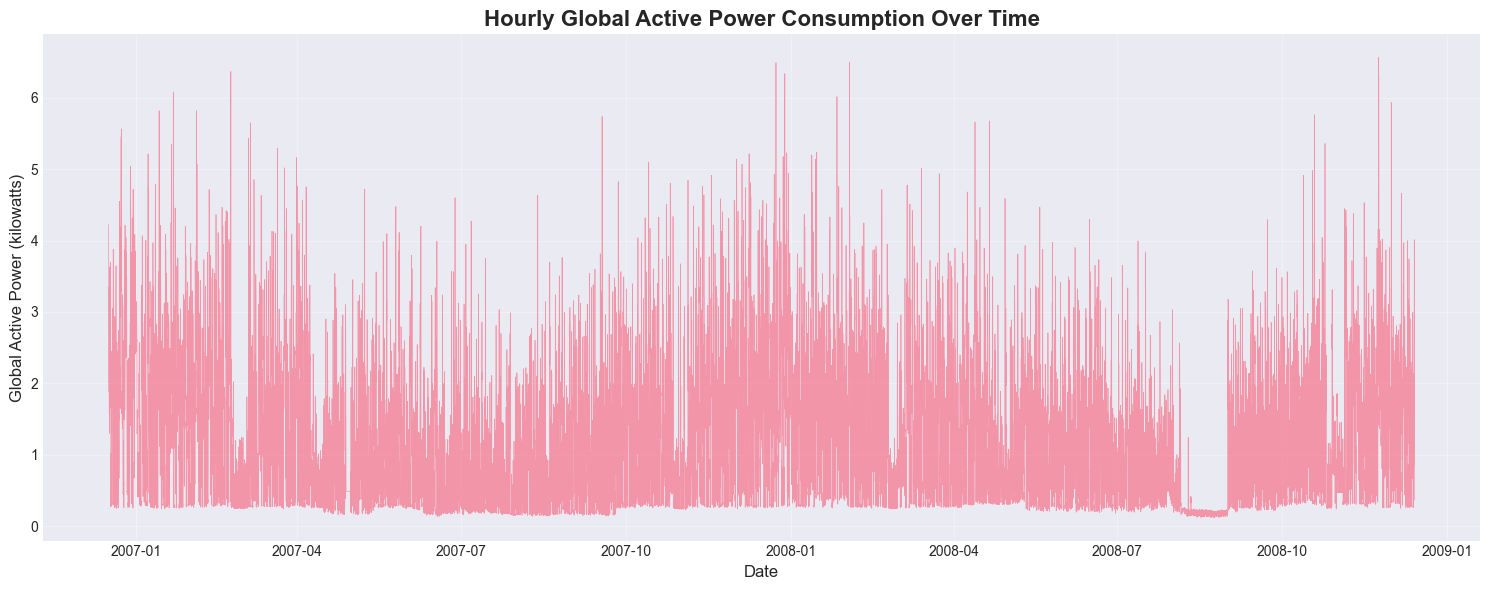

In [17]:
plt.figure(figsize=(15, 6))
plt.plot(df_hourly.index, df_hourly['Global_active_power'], linewidth=0.5, alpha=0.7)
plt.title('Hourly Global Active Power Consumption Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kilowatts)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Daily average pattern

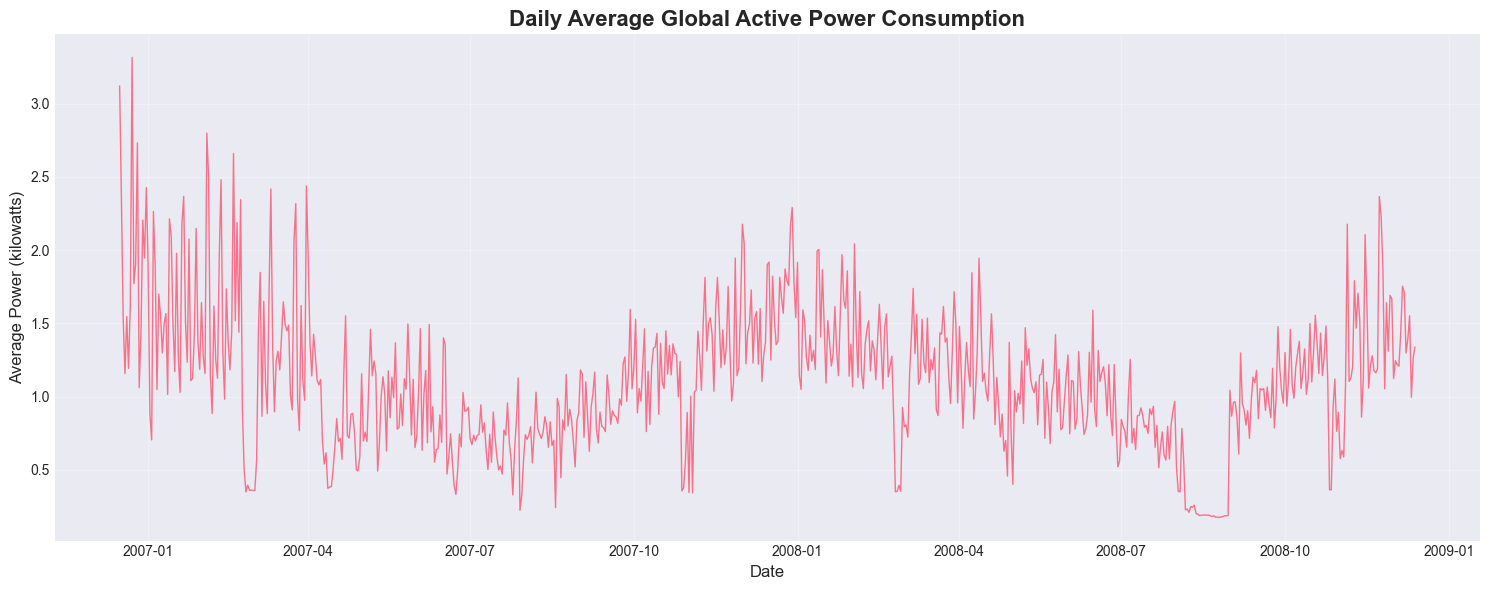

In [18]:
df_daily = df_hourly.resample('D').mean()

plt.figure(figsize=(15, 6))
plt.plot(df_daily.index, df_daily['Global_active_power'], linewidth=1)
plt.title('Daily Average Global Active Power Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Power (kilowatts)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Distribution of power consumption

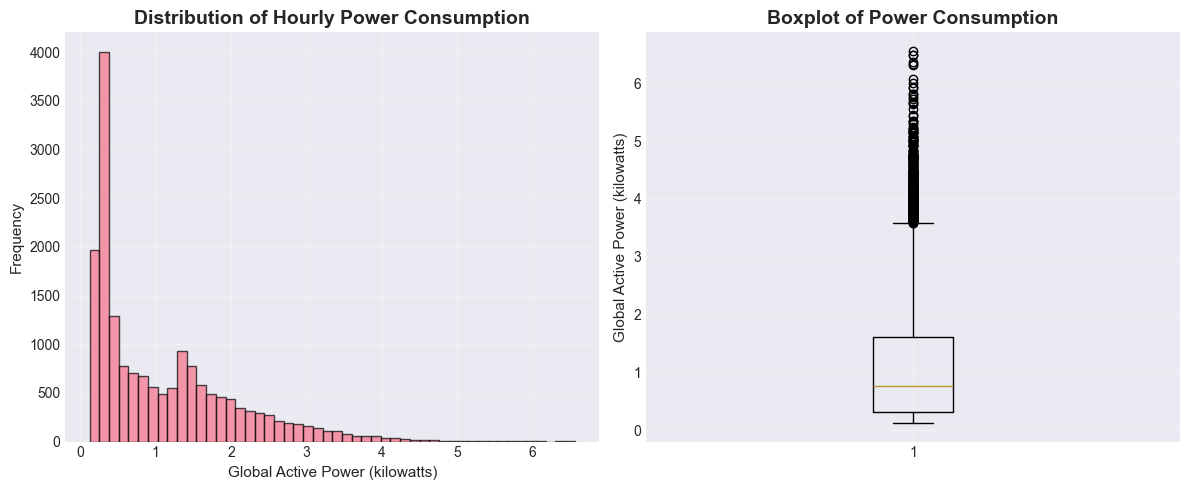

Mean power consumption: 1.11 kW
Median power consumption: 0.77 kW
Std deviation: 0.97 kW


In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_hourly['Global_active_power'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Hourly Power Consumption', fontsize=14, fontweight='bold')
plt.xlabel('Global Active Power (kilowatts)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df_hourly['Global_active_power'], vert=True)
plt.title('Boxplot of Power Consumption', fontsize=14, fontweight='bold')
plt.ylabel('Global Active Power (kilowatts)', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean power consumption: {df_hourly['Global_active_power'].mean():.2f} kW")
print(f"Median power consumption: {df_hourly['Global_active_power'].median():.2f} kW")
print(f"Std deviation: {df_hourly['Global_active_power'].std():.2f} kW")

## Feature Engineering

In [21]:
# Create time-based features
df_features = df.bfill()

# Extract temporal features
df_features['hour'] = df_features.index.hour
df_features['day_of_week'] = df_features.index.dayofweek
df_features['day_of_month'] = df_features.index.day
df_features['month'] = df_features.index.month
df_features['quarter'] = df_features.index.quarter
df_features['year'] = df_features.index.year
df_features['is_weekend'] = (df_features.index.dayofweek >= 5).astype(int)

# Cyclical encoding for hour (to capture 23->0 continuity)
df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)

# Cyclical encoding for day of week
df_features['day_sin'] = np.sin(2 * np.pi * df_features['day_of_week'] / 7)
df_features['day_cos'] = np.cos(2 * np.pi * df_features['day_of_week'] / 7)

# Cyclical encoding for month
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

print("Features created:")
print(df_features.columns.tolist())
print(f"\nDataset shape: {df_features.shape}")
df_features.head()

Features created:
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']

Dataset shape: (1048575, 20)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,day_of_month,month,quarter,year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
datetime,,,,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,5,16,12,4,2006,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,5,16,12,4,2006,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,5,16,12,4,2006,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,5,16,12,4,2006,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,5,16,12,4,2006,1,-0.965926,-0.258819,-0.974928,-0.222521,-2.449294e-16,1.0


### Visualize patterns by hour of day

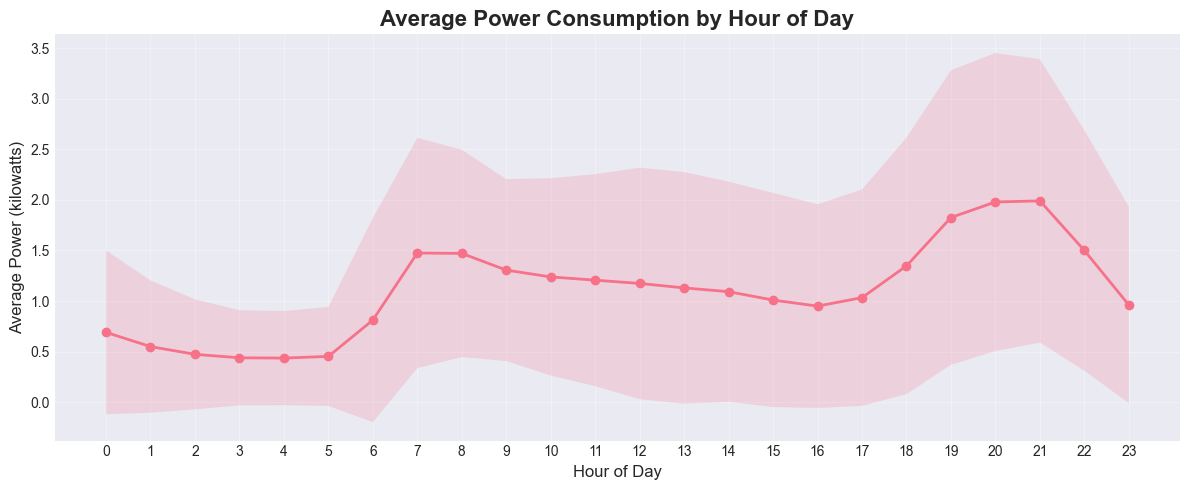

In [22]:
hourly_pattern = df_features.groupby('hour')['Global_active_power'].agg(['mean', 'std'])

plt.figure(figsize=(12, 5))
plt.plot(hourly_pattern.index, hourly_pattern['mean'], marker='o', linewidth=2, markersize=6)
plt.fill_between(hourly_pattern.index, 
                 hourly_pattern['mean'] - hourly_pattern['std'],
                 hourly_pattern['mean'] + hourly_pattern['std'],
                 alpha=0.2)
plt.title('Average Power Consumption by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Power (kilowatts)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualize weekend vs weekday patterns

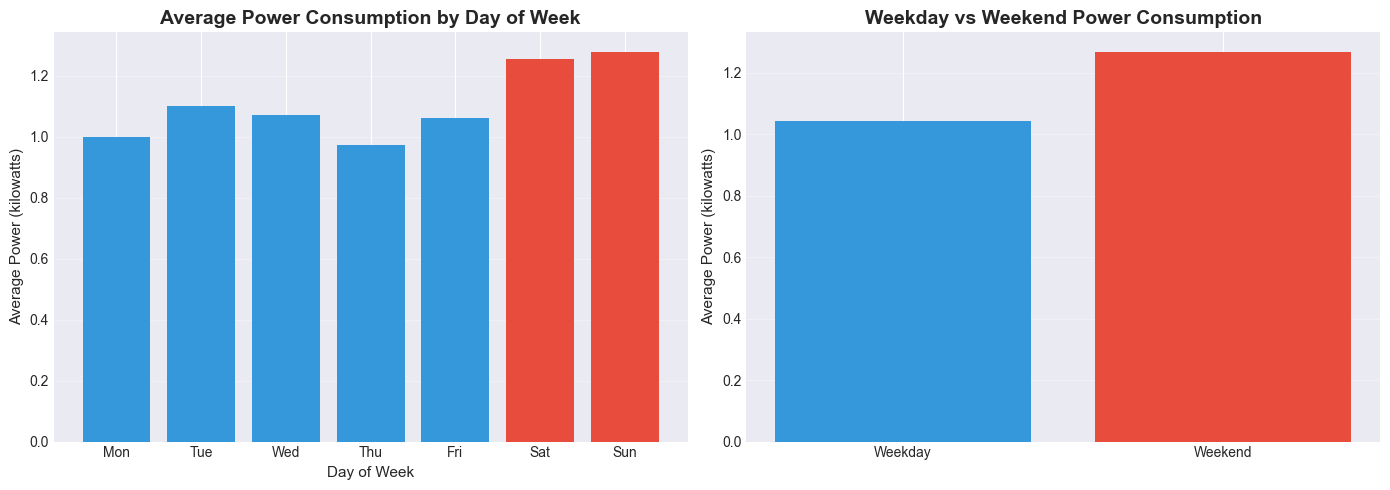

In [23]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
day_pattern = df_features.groupby('day_of_week')['Global_active_power'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(range(7), day_pattern.values, color=['#3498db']*5 + ['#e74c3c']*2)
plt.xticks(range(7), days)
plt.title('Average Power Consumption by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=11)
plt.ylabel('Average Power (kilowatts)', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
weekend_pattern = df_features.groupby('is_weekend')['Global_active_power'].mean()
plt.bar(['Weekday', 'Weekend'], weekend_pattern.values, color=['#3498db', '#e74c3c'])
plt.title('Weekday vs Weekend Power Consumption', fontsize=14, fontweight='bold')
plt.ylabel('Average Power (kilowatts)', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

##  Prepare Data for Modeling
We'll use the last 30 days for testing and the rest for training.

In [24]:
# Use the last 30 days (720 hours) as test set
test_size = 24 * 30  # 30 days

# Split the data
train_data = df_features.iloc[:-test_size]
test_data = df_features.iloc[-test_size:]

print(f"Training set: {len(train_data)} samples ({train_data.index.min()} to {train_data.index.max()})")
print(f"Test set: {len(test_data)} samples ({test_data.index.min()} to {test_data.index.max()})")
print(f"\nTest set duration: {(test_data.index.max() - test_data.index.min()).days} days")

Training set: 1047855 samples (2006-12-16 17:24:00 to 2008-12-13 09:38:00)
Test set: 720 samples (2008-12-13 09:39:00 to 2008-12-13 21:38:00)

Test set duration: 0 days


## Model 1: ARIMA

In [ ]:
print("Preparing data for ARIMA model...")
print("Using daily resampled data to avoid memory issues\n")

# Resample to daily data for ARIMA
df_daily_arima = df_hourly.resample('D').mean()

# Use the last 30 days as test set for ARIMA
test_size_arima = 30  # 30 days
train_arima = df_daily_arima.iloc[:-test_size_arima]['Global_active_power']
test_arima = df_daily_arima.iloc[-test_size_arima:]['Global_active_power']

print(f"ARIMA Training set: {len(train_arima)} days")
print(f"ARIMA Test set: {len(test_arima)} days")

print("\nTraining ARIMA model...")
print("This may take a few minutes...\n")

# Fit ARIMA model
arima_model = ARIMA(train_arima, order=(3, 1, 2))
arima_fit = arima_model.fit(low_memory=True)

print("ARIMA Model Summary:")
print(arima_fit.summary())

# Make predictions (daily)
arima_predictions_daily = arima_fit.forecast(steps=len(test_arima))

# Interpolate daily predictions to hourly
arima_daily_series = pd.Series(arima_predictions_daily.values, index=test_arima.index)
arima_predictions = arima_daily_series.resample('h').interpolate(method='linear')

# Align with the hourly test set
test_arima_hourly = test_data['Global_active_power']
arima_predictions = arima_predictions.reindex(test_arima_hourly.index, method='nearest')

# Calculate metrics
arima_mae = mean_absolute_error(test_arima_hourly, arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(test_arima_hourly, arima_predictions))

print("ARIMA Model Performance")
print(f"MAE:  {arima_mae:.4f} kW")
print(f"RMSE: {arima_rmse:.4f} kW")

Training ARIMA model...
This may take a few minutes...



MemoryError: Unable to allocate 288. MiB for an array with shape (6, 6, 1047855) and data type float64

In [ ]:
# Make predictions
arima_predictions = arima_fit.forecast(steps=len(test_arima))

# Calculate metrics
arima_mae = mean_absolute_error(test_arima, arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_predictions))

print("ARIMA Model Performance")
print(f"MAE:  {arima_mae:.4f} kW")
print(f"RMSE: {arima_rmse:.4f} kW")

## Model 2: Prophet

In [ ]:
print("Training Prophet model...\n")

# Prepare data for Prophet (needs 'ds' and 'y' columns)
train_prophet = pd.DataFrame({
    'ds': train_data.index,
    'y': train_data['Global_active_power'].values
})

test_prophet = pd.DataFrame({
    'ds': test_data.index,
    'y': test_data['Global_active_power'].values
})

# Initialize and fit Prophet model
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

prophet_model.fit(train_prophet)

print("Prophet model trained successfully!")

In [ ]:
# Make predictions
prophet_predictions = prophet_model.predict(test_prophet)

# Calculate metrics
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_predictions['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_predictions['yhat']))

print("Prophet Model Performance")
print(f"MAE:  {prophet_mae:.4f} kW")
print(f"RMSE: {prophet_rmse:.4f} kW")

In [ ]:
# Plot Prophet components
fig = prophet_model.plot_components(prophet_predictions)
plt.tight_layout()
plt.show()

## Model 3: XGBoost

In [ ]:
print("Training XGBoost model...\n")

# Select features for XGBoost
feature_columns = ['hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'is_weekend',
                   'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']

# Add lagged features for better performance
for lag in [1, 2, 24, 168]:  # 1h, 2h, 1day, 1week
    df_features[f'lag_{lag}'] = df_features['Global_active_power'].shift(lag)

# Fill NaN values created by lagging
df_features.fillna(method='bfill', inplace=True)

# Add lagged features to feature columns
lag_features = [f'lag_{lag}' for lag in [1, 2, 24, 168]]
feature_columns.extend(lag_features)

# Prepare train and test sets
X_train = df_features.iloc[:-test_size][feature_columns]
y_train = df_features.iloc[:-test_size]['Global_active_power']
X_test = df_features.iloc[-test_size:][feature_columns]
y_test = df_features.iloc[-test_size:]['Global_active_power']

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"\nFeatures used: {feature_columns}")

In [ ]:
# Train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train, verbose=False)

print("XGBoost model trained successfully!")

In [ ]:
# Make predictions
xgb_predictions = xgb_model.predict(X_test)

# Calculate metrics
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("XGBoost Model Performance")
print(f"MAE:  {xgb_mae:.4f} kW")
print(f"RMSE: {xgb_rmse:.4f} kW")


In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('XGBoost Feature Importance', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

## Model Comparison

In [ ]:
# Compare all models
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE (kW)': [arima_mae, prophet_mae, xgb_mae],
    'RMSE (kW)': [arima_rmse, prophet_rmse, xgb_rmse]
})

comparison['MAE_Rank'] = comparison['MAE (kW)'].rank()
comparison['RMSE_Rank'] = comparison['RMSE (kW)'].rank()

print("MODEL COMPARISON SUMMARY")
print(comparison.to_string(index=False))

best_model = comparison.loc[comparison['MAE (kW)'].idxmin(), 'Model']
print(f"\n Best Model (by MAE): {best_model}")

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison
axes[0].bar(comparison['Model'], comparison['MAE (kW)'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Model Comparison - MAE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error (kW)', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison['MAE (kW)']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# RMSE comparison
axes[1].bar(comparison['Model'], comparison['RMSE (kW)'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('Model Comparison - RMSE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Root Mean Squared Error (kW)', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison['RMSE (kW)']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Visualization: Actual vs Forecasted

In [ ]:
# Prepare data for visualization
test_dates = test_data.index
actual_values = test_data['Global_active_power'].values

# Create comprehensive comparison plot
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

## ARIMA

In [ ]:
axes[0].plot(test_dates, actual_values, label='Actual', linewidth=2, color='black', alpha=0.7)
axes[0].plot(test_dates, arima_predictions, label='ARIMA Forecast', linewidth=2, color='#3498db', alpha=0.8)
axes[0].fill_between(test_dates, actual_values, arima_predictions, alpha=0.2, color='#3498db')
axes[0].set_title(f'ARIMA Model - Actual vs Forecast (MAE: {arima_mae:.4f} kW, RMSE: {arima_rmse:.4f} kW)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Power (kW)', fontsize=11)
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3)

## Prophet

In [ ]:
axes[1].plot(test_dates, actual_values, label='Actual', linewidth=2, color='black', alpha=0.7)
axes[1].plot(test_dates, prophet_predictions['yhat'].values, label='Prophet Forecast', linewidth=2, color='#e74c3c', alpha=0.8)
axes[1].fill_between(test_dates, actual_values, prophet_predictions['yhat'].values, alpha=0.2, color='#e74c3c')
axes[1].set_title(f'Prophet Model - Actual vs Forecast (MAE: {prophet_mae:.4f} kW, RMSE: {prophet_rmse:.4f} kW)', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Power (kW)', fontsize=11)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

## XGBoost

In [ ]:
axes[2].plot(test_dates, actual_values, label='Actual', linewidth=2, color='black', alpha=0.7)
axes[2].plot(test_dates, xgb_predictions, label='XGBoost Forecast', linewidth=2, color='#2ecc71', alpha=0.8)
axes[2].fill_between(test_dates, actual_values, xgb_predictions, alpha=0.2, color='#2ecc71')
axes[2].set_title(f'XGBoost Model - Actual vs Forecast (MAE: {xgb_mae:.4f} kW, RMSE: {xgb_rmse:.4f} kW)', 
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Power (kW)', fontsize=11)
axes[2].legend(loc='upper right', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zoomed-in view (first 7 days of test set)

In [ ]:
zoom_days = 7
zoom_hours = zoom_days * 24

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

## ARIMA

In [ ]:
axes[0].plot(test_dates[:zoom_hours], actual_values[:zoom_hours], label='Actual', linewidth=2.5, color='black', marker='o', markersize=3)
axes[0].plot(test_dates[:zoom_hours], arima_predictions[:zoom_hours], label='ARIMA Forecast', linewidth=2.5, color='#3498db', marker='s', markersize=3)
axes[0].set_title(f'ARIMA - First {zoom_days} Days Detail View', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Power (kW)', fontsize=11)
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3)

## Prophet

In [ ]:
axes[1].plot(test_dates[:zoom_hours], actual_values[:zoom_hours], label='Actual', linewidth=2.5, color='black', marker='o', markersize=3)
axes[1].plot(test_dates[:zoom_hours], prophet_predictions['yhat'].values[:zoom_hours], label='Prophet Forecast', linewidth=2.5, color='#e74c3c', marker='s', markersize=3)
axes[1].set_title(f'Prophet - First {zoom_days} Days Detail View', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Power (kW)', fontsize=11)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

## XGBoost

In [ ]:
axes[2].plot(test_dates[:zoom_hours], actual_values[:zoom_hours], label='Actual', linewidth=2.5, color='black', marker='o', markersize=3)
axes[2].plot(test_dates[:zoom_hours], xgb_predictions[:zoom_hours], label='XGBoost Forecast', linewidth=2.5, color='#2ecc71', marker='s', markersize=3)
axes[2].set_title(f'XGBoost - First {zoom_days} Days Detail View', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Power (kW)', fontsize=11)
axes[2].legend(loc='upper right', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## All models on one plot for comparison

In [ ]:
plt.figure(figsize=(18, 8))

plt.plot(test_dates, actual_values, label='Actual', linewidth=2.5, color='black', alpha=0.9, zorder=5)
plt.plot(test_dates, arima_predictions, label=f'ARIMA (MAE: {arima_mae:.4f})', linewidth=2, color='#3498db', alpha=0.7, linestyle='--')
plt.plot(test_dates, prophet_predictions['yhat'].values, label=f'Prophet (MAE: {prophet_mae:.4f})', linewidth=2, color='#e74c3c', alpha=0.7, linestyle='-.')
plt.plot(test_dates, xgb_predictions, label=f'XGBoost (MAE: {xgb_mae:.4f})', linewidth=2, color='#2ecc71', alpha=0.7, linestyle=':')

plt.title('All Models Comparison - Actual vs Forecasted Power Consumption', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Global Active Power (kilowatts)', fontsize=14)
plt.legend(loc='upper right', fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Residual Analysis

In [ ]:
# Calculate residuals
arima_residuals = actual_values - arima_predictions
prophet_residuals = actual_values - prophet_predictions['yhat'].values
xgb_residuals = actual_values - xgb_predictions

# Plot residuals
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

## ARIMA

In [ ]:
axes[0, 0].plot(test_dates, arima_residuals, color='#3498db', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('ARIMA Residuals Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (kW)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(arima_residuals, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('ARIMA Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residuals (kW)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

## Prophet

In [ ]:
axes[1, 0].plot(test_dates, prophet_residuals, color='#e74c3c', alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Prophet Residuals Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (kW)', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(prophet_residuals, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title('Prophet Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Residuals (kW)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

## XGBoost

In [ ]:
axes[2, 0].plot(test_dates, xgb_residuals, color='#2ecc71', alpha=0.7)
axes[2, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[2, 0].set_title('XGBoost Residuals Over Time', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Date', fontsize=10)
axes[2, 0].set_ylabel('Residuals (kW)', fontsize=10)
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].hist(xgb_residuals, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[2, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2, 1].set_title('XGBoost Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Residuals (kW)', fontsize=10)
axes[2, 1].set_ylabel('Frequency', fontsize=10)
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Residual statistics

In [ ]:
residual_stats = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'Mean Residual': [arima_residuals.mean(), prophet_residuals.mean(), xgb_residuals.mean()],
    'Std Residual': [arima_residuals.std(), prophet_residuals.std(), xgb_residuals.std()],
    'Min Residual': [arima_residuals.min(), prophet_residuals.min(), xgb_residuals.min()],
    'Max Residual': [arima_residuals.max(), prophet_residuals.max(), xgb_residuals.max()]
})

print("RESIDUAL ANALYSIS")
print(residual_stats.to_string(index=False))

## Key Insights and Conclusions

In [ ]:
print("KEY INSIGHTS")

print("\n1. DATA PATTERNS:")
print(f"   • Dataset covers {(df_hourly.index.max() - df_hourly.index.min()).days} days")
print(f"   • Average power consumption: {df_hourly['Global_active_power'].mean():.2f} kW")
print(f"   • Peak consumption hour: {df_features.groupby('hour')['Global_active_power'].mean().idxmax()}:00")
print(f"   • Lowest consumption hour: {df_features.groupby('hour')['Global_active_power'].mean().idxmin()}:00")

print("\n2. MODEL PERFORMANCE:")
for idx, row in comparison.iterrows():
    print(f"   • {row['Model']}: MAE = {row['MAE (kW)']:.4f} kW, RMSE = {row['RMSE (kW)']:.4f} kW")

print(f"\n3. BEST MODEL: {best_model}")
print(f"   • Achieved lowest MAE of {comparison['MAE (kW)'].min():.4f} kW")
print(f"   • RMSE of {comparison.loc[comparison['MAE (kW)'].idxmin(), 'RMSE (kW)']:.4f} kW")

print("\n4. FEATURE IMPORTANCE (XGBoost):")
top_features = feature_importance.head(5)
for idx, row in top_features.iterrows():
    print(f"   • {row['feature']}: {row['importance']:.4f}")

print("\n5. TEMPORAL PATTERNS:")
print(f"   • Weekday avg consumption: {df_features[df_features['is_weekend']==0]['Global_active_power'].mean():.2f} kW")
print(f"   • Weekend avg consumption: {df_features[df_features['is_weekend']==1]['Global_active_power'].mean():.2f} kW")

print("\n Analysis Complete!")

## Skills Gained
-> **Time Series Forecasting**: Implemented ARIMA, Prophet, and XGBoost models

-> **Feature Engineering**: Created temporal features (hour, day, weekend flags) and cyclical encodings

-> **Model Comparison**: Evaluated models using MAE and RMSE metric

-> **Temporal Data Visualization**: Created comprehensive plots for actual vs forecasted values

-> **Residual Analysis**: Analyzed prediction errors and model performance patterns